In [9]:
%pip install yake pandas matplotlib numpy pytz

In [10]:
#using it to do the preprocessing of the text input of the chat messages
import yake
import requests
import json
import datetime
import pytz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import voice_to_speech as vts

tz = pytz.timezone('Africa/Johannesburg')

In [11]:
text = "Sources tell us that Google is acquiring Kaggle, a platform that hosts data science and machine learning competitions. Details about the transaction remain somewhat vague, but given that Google is hosting its Cloud Next conference in San Francisco this week, the official announcement could come as early as tomorrow. Reached by phone, Kaggle co-founder CEO Anthony Goldbloom declined to deny that the acquisition is happening. Google itself declined 'to comment on rumors'. Kaggle, which has about half a million data scientists on its platform, was founded by Goldbloom  and Ben Hamner in 2010. The service got an early start and even though it has a few competitors like DrivenData, TopCoder and HackerRank, it has managed to stay well ahead of them by focusing on its specific niche. The service is basically the de facto home for running data science and machine learning competitions. With Kaggle, Google is buying one of the largest and most active communities for data scientists - and with that, it will get increased mindshare in this community, too (though it already has plenty of that thanks to Tensorflow and other projects). Kaggle has a bit of a history with Google, too, but that's pretty recent. Earlier this month, Google and Kaggle teamed up to host a $100,000 machine learning competition around classifying YouTube videos. That competition had some deep integrations with the Google Cloud Platform, too. Our understanding is that Google will keep the service running - likely under its current name. While the acquisition is probably more about Kaggle's community than technology, Kaggle did build some interesting tools for hosting its competition and 'kernels', too. On Kaggle, kernels are basically the source code for analyzing data sets and developers can share this code on the platform (the company previously called them 'scripts'). Like similar competition-centric sites, Kaggle also runs a job board, too. It's unclear what Google will do with that part of the service. According to Crunchbase, Kaggle raised $12.5 million (though PitchBook says it's $12.75) since its   launch in 2010. Investors in Kaggle include Index Ventures, SV Angel, Max Levchin, Naval Ravikant, Google chief economist Hal Varian, Khosla Ventures and Yuri Milner "

# text = ' Using a cloud service, rather than running comparable software yourself, essentially outsources the operation of that software to the cloud provider. There are good arguments for and against cloud services. Cloud providers claim that using their services saves you time and money, and allows you to move faster compared to setting up your own infrastructure.'
# text = 'Cloud providers claim that using their services saves you time and money, and allows you to move faster compared to setting up your own infrastructure'

#i want to implement the cleaning myself butonly a bit later on


In [12]:

#find a better more general keyword extractor (?)
# With custom parameters
custom_kw_extractor = yake.KeywordExtractor(
    lan="en",              # language
    n=2,                   # ngram size
    dedupLim=0.9,          # deduplication threshold
    dedupFunc='seqm',      # deduplication function
    windowsSize=1,         # context window
    top=2,                # number of keywords to extract
    features=None,         # custom features
    stopwords=None
)

#lower score means more importantrelevent a keyword is
keywords = custom_kw_extractor.extract_keywords(text)

In [13]:
keyword_list = ''
max_page_suggestions = 3

for word in keywords:
    keyword_list += (word[0]) + ','
    # print(word[0])

#find a better API
url = 'https://en.wikipedia.org/w/rest.php/v1/search/page'
headers = {
    'User-Agent': 'MediaWiki REST API docs examples/0.1 (https://www.mediawiki.org/wiki/API_talk:REST_API)'
}
params = {
    'q': keyword_list,
    'limit': max_page_suggestions
}
response = requests.get(url, headers=headers, params=params)

In [ ]:

requestlink = response.url

# response.json() turns the recieved response into a python DS
data = response.json()

#dump turns python DS into a json string
requestlink = response.url

# response.json() turns the recieved response into a python DS
data = response.json()

#dump turns python DS into a json string
results_json = json.dumps(data, indent=2)
# results_python = json.load(data)


print(requestlink)
# print(results_json)

results_json = json.dumps(data, indent=2)
# results_python = json.load(data)
#.split('.')[0] is used to remove the extra precision points in the time stamp 
df = pd.DataFrame()

17.4 µs ± 4.2 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)
https://en.wikipedia.org/w/rest.php/v1/search/page?q=Google%2CKaggle%2C&limit=3


In [15]:
def timestamp_now():
    return pd.to_datetime(pd.Timestamp.now('Africa/Johannesburg'))
# dataframe format 
entry_series = {
    'timestamp':                [timestamp_now()],
    'Main Topic':               [data['pages'][0]['title']],
    'Main Topic description':   [data['pages'][0]['description']],
    'Second Topic':             [data['pages'][1]['title']],
    'Second Topic description': [data['pages'][1]['description']]
    }

entry_series = pd.DataFrame(entry_series)

entry_series['Time'] = entry_series['timestamp'].dt.strftime("%H:%M:%S")
df = pd.concat([df, entry_series], ignore_index=True)
df

,timestamp,Main Topic,Main Topic description,Second Topic,Second Topic description,Time
0,2026-07-11 23:40:56.212891+02:00,Kaggle,Internet platform for data science competitions,Google Gemini,Chatbot developed by Google,23:40:56


In [16]:
# this is the format for the dataframe
# topic_timeline = {
#     'timestamp': [],
#     'Main Topic':[],
#     'Main Topic description':[],
#     'Second Topic':[],
#     'Second Topic description': []
#     }
# print(entry_series)


In [17]:
# entry_series = {
#     'timestamp':                 [time],
#     'Main Topic':               [data['pages'][0]['title']],
#     'Main Topic description':   [data['pages'][0]['description']],
#     'Second Topic':             [data['pages'][1]['title']],
#     'Second Topic description': [data['pages'][1]['description']]
#     }

# entry_series = pd.DataFrame(entry_series)

# df['timestamp'] = pd.to_datetime(df['datetime'])
df.dtypes
df

,timestamp,Main Topic,Main Topic description,Second Topic,Second Topic description,Time
0,2026-07-11 23:40:56.212891+02:00,Kaggle,Internet platform for data science competitions,Google Gemini,Chatbot developed by Google,23:40:56


In [18]:
# df = df.sort_values(by='Time')
# df = df.reset_index(drop=True)
df

,timestamp,Main Topic,Main Topic description,Second Topic,Second Topic description,Time
0,2026-07-11 23:40:56.212891+02:00,Kaggle,Internet platform for data science competitions,Google Gemini,Chatbot developed by Google,23:40:56


In [19]:
#rn i just wanna make a list of time values in a list that i can reference anytime i need to 
topic_timeline = df.copy()

In [20]:

topic_timeline["Level"] = [np.random.randint(-6,-2) if (i%2)==0 else np.random.randint(2,6) for i in range(len(topic_timeline))]
topic_timeline

,timestamp,Main Topic,Main Topic description,Second Topic,Second Topic description,Time,Level
0,2026-07-11 23:40:56.212891+02:00,Kaggle,Internet platform for data science competitions,Google Gemini,Chatbot developed by Google,23:40:56,-6


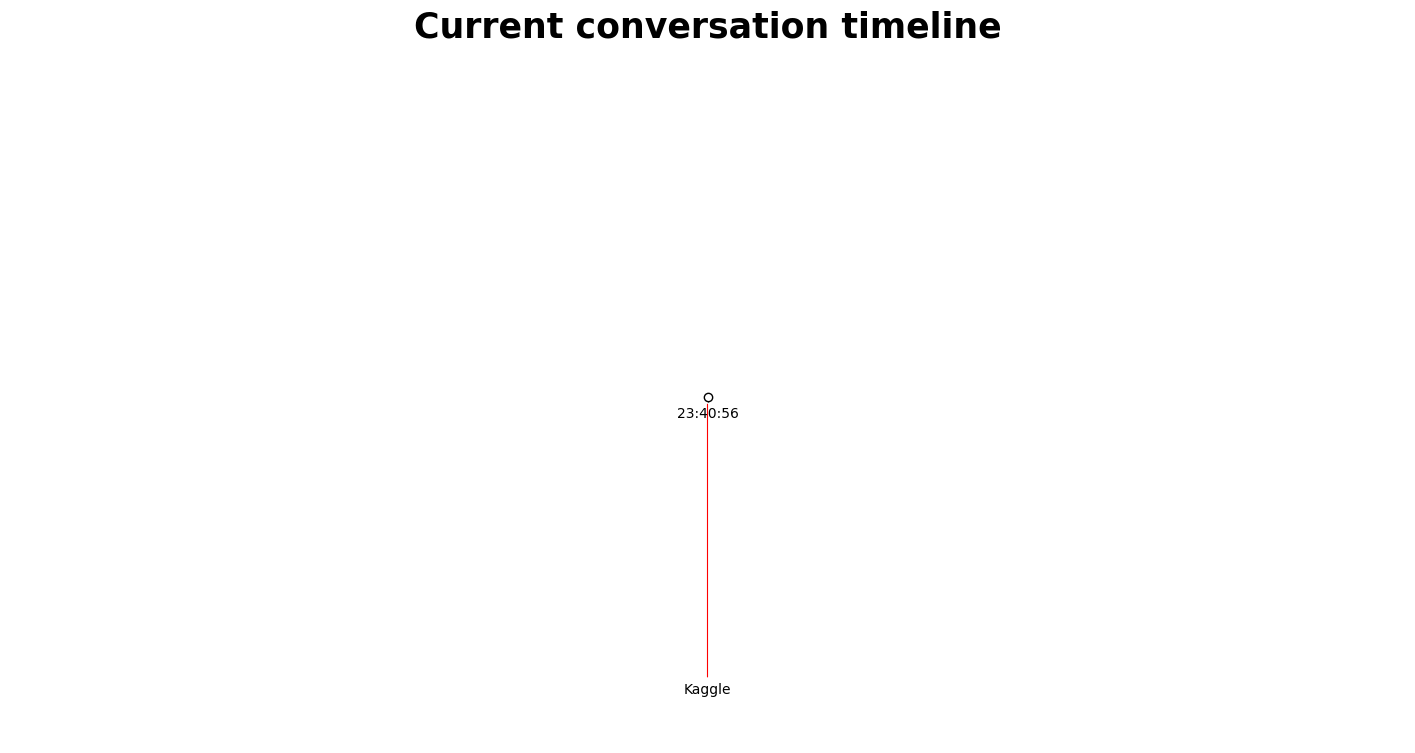

In [21]:
fig, ax = plt.subplots(figsize=(18,9))

# here we are plotting a straight black line with the df['Time] values and the data points (with shape "-o" and in black) will be placed in their positions
# [0,]* len(df) is the y values for the graph(as a list), where we are telling it to put all the markers at y=0 for the length of the straight line
ax.plot(topic_timeline['Time'], [0,]* len(df), "-o", color="black", markerfacecolor="white")

# remember to try out the generated library for the time range thing #import clock
# start = df['Time'][0]
# end = df['Time'][len(df)-1]

# times = pd.date_range(
#     start=start,
#     end=end,
#     freq="1min"
# )

# print(times)

# ax.set_xticks(times)
ax.set_ylim(-7,7)

for idx in range(len(topic_timeline)):
    time, topic, level = topic_timeline["Time"][idx], topic_timeline["Main Topic"][idx], topic_timeline["Level"][idx]
    ax.annotate(topic, xy=(time, 0.1 if level>0 else -0.1),xytext=(time, level),
                arrowprops=dict(arrowstyle="-",color="red", linewidth=0.8),
                ha="center"
               );

ax.spines[["left", "top", "right", "bottom"]].set_visible(False)
ax.spines[["bottom"]].set_position(("axes", 0.5))
ax.yaxis.set_visible(False)
ax.set_title("Current conversation timeline", pad=10, loc="center", fontsize=25, fontweight="bold")
plt.show()